In [1]:
# Parameters
config_path = "setups/2033/AD_proposal_paper/skew_example.yml"
atom_data = "kurucz_cd23_chianti_H_He_latest"


# TARDIS Config Report
Auto-generated prototype notebook for a single config.

In [2]:
# Parameters
config_path = globals().get("config_path", None)  # Path to TARDIS config file
atom_data = globals().get("atom_data", "kurucz_cd23_chianti_H_He_latest")  # Atom data identifier

In [3]:
from pathlib import Path
from IPython.display import display
from tardis import run_tardis
from tardis.io.configuration.config_reader import Configuration
from tardis.visualization import (
    SDECPlotter,
    LIVPlotter,
    RPacketPlotter,
    LineInfoWidget,
    GrotrianWidget,
    CustomAbundanceWidget,
    shell_info_from_simulation,
)

Initializing tabulator and plotly panel extensions for widgets to work


In [4]:
config = Configuration.from_yaml(config_path)
try:
    config.montecarlo.tracking.track_rpacket = True
except Exception:
    pass
try:
    sim = run_tardis(config, atom_data=atom_data, virtual_packet_logging=True, show_convergence_plots=True)
except RuntimeError as exc:
    if 'Convergence Plots cannot be displayed in command-line' not in str(exc):
        raise
    sim = run_tardis(config, atom_data=atom_data, virtual_packet_logging=True, show_convergence_plots=False)
print('Simulation complete for', Path(config_path).name)

Auto-detected Jupyter notebook environment


Auto-detected Jupyter notebook environment


Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

BokehModel(combine_events=True, render_bundle={'docs_json': {'07a0f1be-65d0-48dd-9c01-b1dde776e133': {'version…

    'data': [{'type': 'scatter', 'uid': 'c26f9b70-1a07-42e1-b673-d2584112fb5c', …

Embedding the final state for Jupyter environments


Simulation complete for skew_example.yml


## Monte Carlo Packet Visualization (Plotly)
This mirrors TARDIS docs style by using `RPacketPlotter` for browser-side interactive packet trajectory plots.

In [5]:
try:
    rpacket_plotter = RPacketPlotter.from_simulation(sim, no_of_packets=20)
    rpacket_fig = rpacket_plotter.generate_plot(theme='light')
    try:
        rpacket_fig.show(renderer='notebook_connected')
    except Exception:
        rpacket_fig.show()
except Exception as exc:
    print(f'RPacket Plotly visualization unavailable: {exc}')

## Interactive Widgets (Optional)
These widget cells use TARDIS visualization widgets when available and skip gracefully in non-interactive environments.

In [6]:
widgets = {}

try:
    widgets['shell_info'] = shell_info_from_simulation(sim)
    print('Shell Info widget ready')
except Exception as exc:
    print(f'Shell Info widget unavailable: {exc}')

try:
    widgets['line_info'] = LineInfoWidget.from_simulation(sim)
    print('Line Info widget ready')
except Exception as exc:
    print(f'Line Info widget unavailable: {exc}')

try:
    widgets['grotrian'] = GrotrianWidget.from_simulation(sim)
    print('Grotrian widget ready')
except Exception as exc:
    print(f'Grotrian widget unavailable: {exc}')

try:
    widgets['custom_abundance'] = CustomAbundanceWidget.from_yml(config_path)
    print('Custom Abundance widget ready')
except Exception as exc:
    print(f'Custom Abundance widget unavailable: {exc}')

Shell Info widget ready
Line Info widget ready


Grotrian widget unavailable: The 'min' trait of a FloatRangeSlider instance expected a float, not the NoneType None.
[tardis.io.atom_data.util][INFO   ]  
	Atom Data kurucz_cd23_chianti_H_He_latest.h5 not found in local path.
	Exists in TARDIS Data repo /home/azureuser/Downloads/tardis-data/kurucz_cd23_chianti_H_He_latest.h5 (util.py:33)


[tardis.io.atom_data.base][INFO   ]  Reading Atom Data with: UUID = b58b2ef63bf811f08edf96479f911fbd MD5  = 5d80fa4ae0638469bf1ff281b6ca2a94  (base.py:258)


[tardis.io.atom_data.base][INFO   ]  Non provided Atomic Data: levels, lines, collision_data, collision_data_temperatures, synpp_refs, photoionization_data, yg_data, two_photon_data, linelist_atoms, linelist_molecules (base.py:262)


[tardis.io.model.parse_composition_configuration][WARNING]  Number of density points larger than number of shells. Assuming inner point irrelevant (parse_composition_configuration.py:63)


[tardis.io.model.parse_mass_fraction_configuration][WARNING]  model_isotope_time_0 is not set in the configuration. Isotopic mass fractions will not be decayed and is assumed to be correct for the time_explosion. THIS IS NOT RECOMMENDED! (parse_mass_fraction_configuration.py:101)


Custom Abundance widget ready


In [7]:
for widget_name, widget_obj in widgets.items():
    print(f'Displaying widget: {widget_name}')
    rendered = False
    try:
        display(widget_obj)
        rendered = True
    except Exception as exc:
        try:
            widget_obj.display()
            rendered = True
        except Exception as inner_exc:
            print(f'Interactive render unavailable for {widget_name}: {inner_exc}')

    fallback_shown = False
    for attr in ('dataframe', 'df', 'table', 'data', 'value'):
        if not hasattr(widget_obj, attr):
            continue
        candidate = getattr(widget_obj, attr)
        if candidate is None:
            continue
        print(f'Static fallback from attribute: {attr}')
        try:
            display(candidate)
            fallback_shown = True
            break
        except Exception:
            continue

    if not rendered and not fallback_shown:
        print(f'No static fallback available for {widget_name}.')

Displaying widget: shell_info


Static fallback from attribute: data


Displaying widget: line_info


Displaying widget: custom_abundance


Static fallback from attribute: data


## SDEC Visualizations

<Axes: xlabel='$\\text{Wavelength}\\,[\\mathrm{\\mathring{A}}]$', ylabel='$L_{\\lambda}\\,[\\mathrm{erg\\,s^{-1}\\,\\mathring{A}^{-1}}]$'>

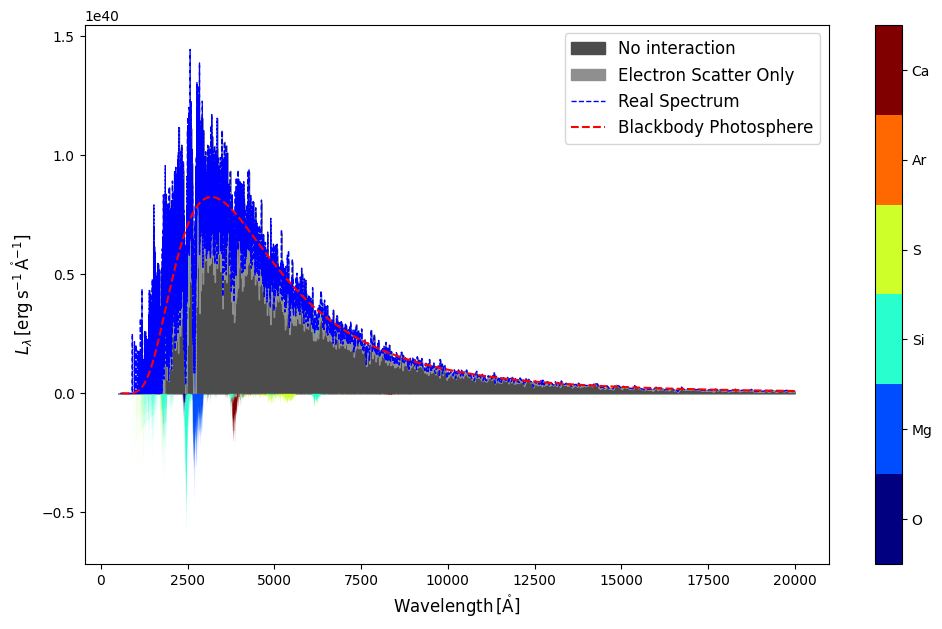

In [8]:
sdec = SDECPlotter.from_simulation(sim)
sdec.generate_plot_mpl(packets_mode='real')

<Axes: xlabel='$\\text{Wavelength}\\,[\\mathrm{\\mathring{A}}]$', ylabel='$L_{\\lambda}\\,[\\mathrm{erg\\,s^{-1}\\,\\mathring{A}^{-1}}]$'>

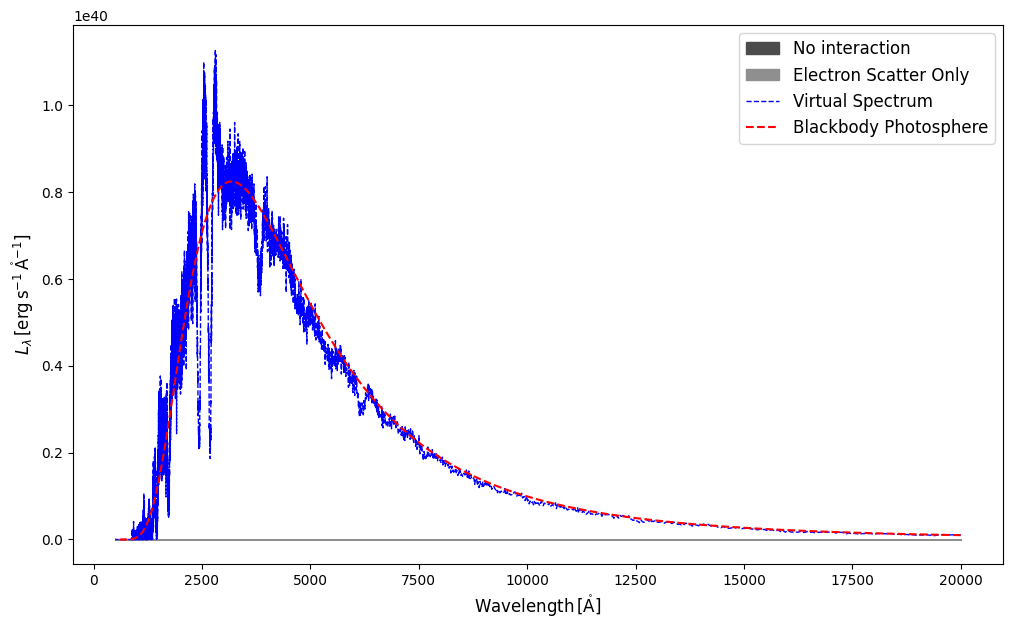

In [9]:
sdec.generate_plot_mpl(packets_mode='virtual')

## LIV Visualizations

<Axes: xlabel='Last Interaction Velocity (km/s)', ylabel='Packet Count'>

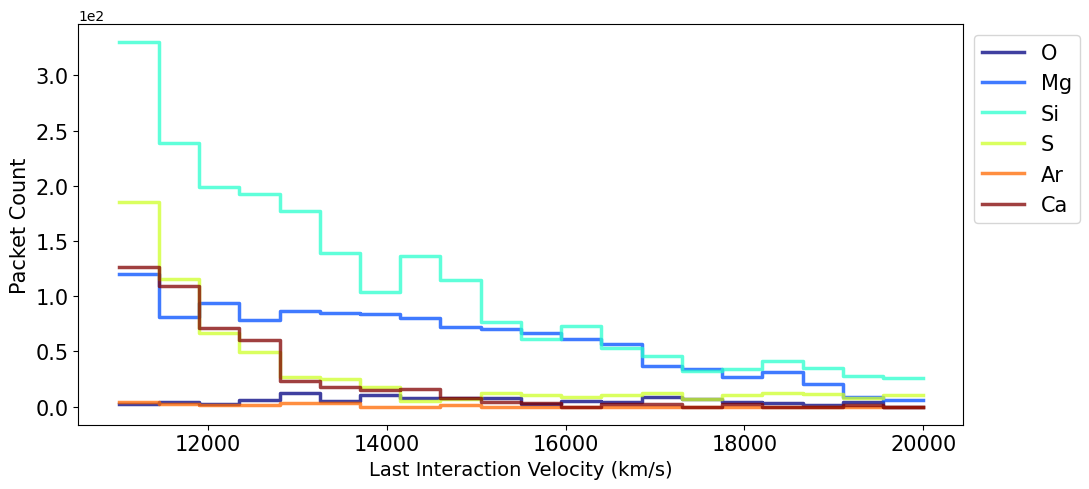

In [10]:
liv = LIVPlotter.from_simulation(sim)
liv.generate_plot_mpl(packets_mode='real')

<Axes: xlabel='Last Interaction Velocity (km/s)', ylabel='Packet Count'>

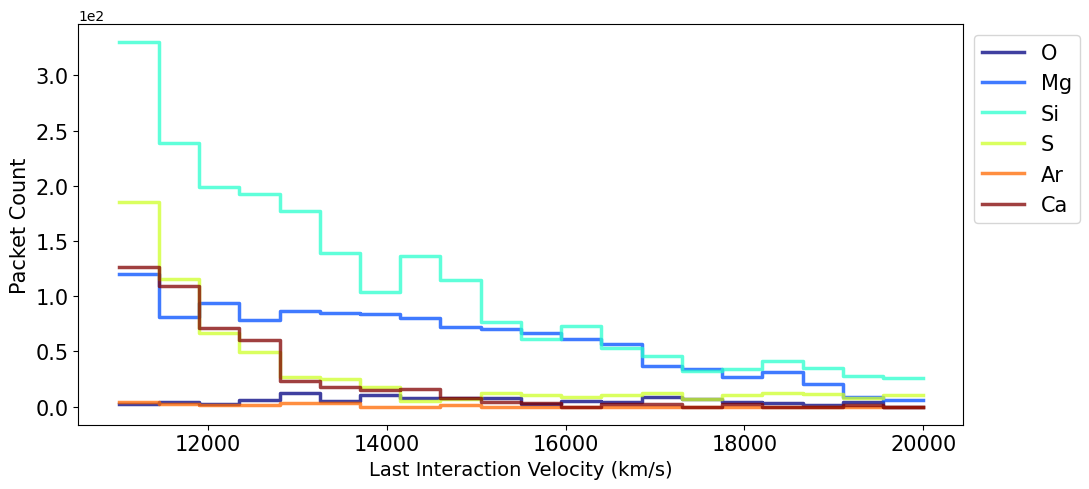

In [11]:
liv.generate_plot_mpl(packets_mode='virtual')

## Convergence Visualizations (If Available)
Convergence plots are shown when available in the simulation object.

In [12]:
try:
    if hasattr(sim, 'convergence_plots') and sim.convergence_plots is not None:
        sim.convergence_plots.plasma_plot.show(renderer='notebook_connected')
        sim.convergence_plots.t_inner_luminosities_plot.show(renderer='notebook_connected')
    else:
        print('Convergence plots are not present. Enable show_convergence_plots=True in run_tardis to generate them.')
except Exception as exc:
    print(f'Could not display convergence plots: {exc}')